<img src="LOGO ITQ (2).png" width="200">

# **Ejercicio Práctico**
### **Nombre:** Mónica Guano
#### **Fecha:** 06/05/2026

# Práctica Académica
## Normalización y Estandarización de Datos en Inteligencia Artificial
# Análisis y aplicación de técnicas de normalización y estandarización en conjunto de datos para modelos de aprendizaje automático
### Objetivo General
Aplicar Técnicas de normalización y estandarización de datos mediante herramientas de python, con el fin de comprender su impacto en la prepación de datos y en el desempeño de modelos de aprendizaje automático.<br>
### Objetivos especificos
* Identificar diferencias de escala entre variables numércias.
* Aplicar técnicas de normalización (Min-Max)
* Aplicar técnicas de estandarización (Z-score)
* Analizar la importancia del preprocesaminto en modelos de IA
### Antecedentes /Fundamentación teórica
En el contexto del aprendizaje automático, los algoritmos suelen verse afectados por la escala de los datos. Variables con valores grandes pueden dominar el comportamiento del modelo, generando sesgos y resultados pocos conficables.<br>
Para mitigar este problema, se emplea técnicas como:
* **Normalización**: transforma los datos a un rango especifico (generalmente[0,1])
* **Estandarización**: ajusta los datos para que tengan mdia 0 y desviación estandar 1.
Estas técnicas son fundamentales en algoritmos como:
* KNN
* Regresión logística
* Redes neuronales
### Escenario de práctica
Una empresa de análisis de datos desea desarrollar modelos predictivos utilizando información de clientes. Sin embargo, se ha identificado que las variables presentan diferentes escalas, lo que puede afectar el rendimiento de los modelos.<br>
Se soliciata al analista aplicar tecnicas de preprocesamiento y limpieza de datos para mejorar la calidad de lso datos.<br>
## Conjunto de datos  utilizar
Dataset 1(Conceptual): Iris dataset <br>
Dataset 2 (aplicación real): California Housing Dataset<br>



In [4]:
#Importacion de librerias 
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing

In [5]:
#Configuramos el entorno de descarga
import os
os.environ['KAGGLE_CONFIG_DIR']="C:/Users/monig/.kaggle"

In [6]:
#Creamos la carpeta dataset
os.makedirs("dataset", exist_ok=True)

In [7]:
#Descargamos el dataset
!kaggle datasets download -d uciml/iris

Dataset URL: https://www.kaggle.com/datasets/uciml/iris
License(s): CC0-1.0
iris.zip: Skipping, found more recently modified local copy (use --force to force download)


In [8]:
#Descompriminos el archivo 
with zipfile.ZipFile("iris.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [9]:
#Cargamos el conjunto de datos
df = pd.read_csv("dataset/Iris.csv")

In [10]:
#mostramos el conjunto de datos"
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [68]:
#Eliminamos columnas innecesarias en la limpieza de datos como vemos en el dataframe la columna id no aporta
#nada a nuestro modelo por lo tanto lo eliminamos 
if 'Id' in df.columns:
    df=df.drop(columns=["Id"])

In [69]:
#Mostramos los detalles de nuesto dataset
df.info()
#Vrificamos si tenemos datos nulos si lo tenemos lo sumamos 
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [70]:
#Separamos los datos de entrada con nuestra variable objetivo 
X=df.drop(columns=['Species'])
y=df['Species']

In [71]:
#Exploramos o generamos un analis exploratorio del conjutno de datos
X.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Conclusión 
Cuando observamos la tabla, lo primero que se observa es que cada variable tiene valores diferentes en tamaño y rango<b>
Por ejemplo<br>
* **PetalLengthCm** tiene valores desde 1.0 hasta 6.9, lo que significa que varia bastante
* En cambio, **SepalWidthCm** va aproximadamente de 2.0 a 4.4 es decir, tiene meno variación.
Esto nos dice que no todas las variables están en la misma escala.
### Qué significa?
Al ver los datos vemos que algunas variables tiene números más grandes que otras, y en modelos como KNN.<br>
* Los números grandes "pesan más"
* Influyen más en el resultado.
Sino hacemos nada y trabajamos con estos datos el modelo va a tomar decisiones basadas en el argumeto **PetalLengtnCm** y menos en otras variables. Esto no es lo conveniento y a esto lo llamamos sesgo.<br>
Para no tener sesgo dentro de nuestros datos lo que hacemos es:
* Normalización
* Estandarización
Esto permite que las variables esten en la misma celda y tengan la misma importancia.


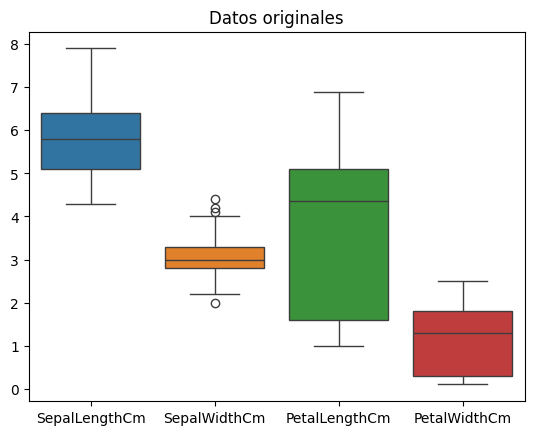

In [72]:
#dibujamos los datos originales 
sns.boxplot(data=X)
#Ponemos un titulo a la imagen 
plt.title("Datos originales")
plt.show()

## Interpretación de la imagen 
Este gráfico nos permite observar que los datos no están en la misma escala y que algunas variables tienen mayor variabilidad que otras. Esto puede afectar el comportamiento de los modeos de inteligencia artifical, por lo que es necesario aplicar técnicas como la normalización o estandarización para equilibrar la influencia de todas las varaibles.


In [73]:
#Normalizamos el conjunto de datos 
normalizer = preprocessing.MinMaxScaler()
X_norm=normalizer.fit_transform(X)
X_norm = pd.DataFrame(X_norm, columns=X.columns)
X_norm.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667


In [74]:
X_norm.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,0.428704,0.439167,0.467571,0.457778
std,0.230018,0.180664,0.299054,0.317984
min,0.000000,0.000000,0.000000,0.000000
25%,0.222222,0.333333,0.101695,0.083333
50%,0.416667,0.416667,0.567797,0.500000
75%,0.583333,0.541667,0.694915,0.708333
max,1.000000,1.000000,1.000000,1.000000


In [75]:
#Estandarización 
standarizer = preprocessing.StandardScaler()
#Estandarizamos los datos
X_std=standarizer.fit_transform(X)
X_std= pd.DataFrame(X_std, columns=X.columns)
X_std.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977


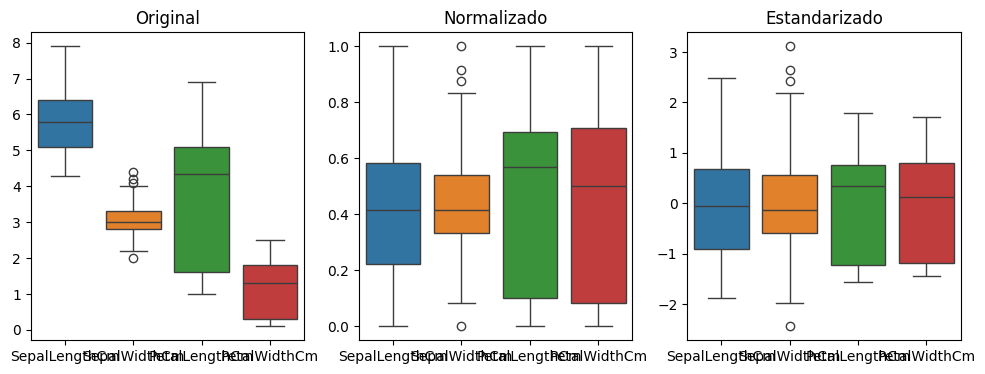

In [76]:
#Comporación visual
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.boxplot(data=X)
plt.title("Original")

plt.subplot(1,3,2)
sns.boxplot(data=X_norm)
plt.title("Normalizado")

plt.subplot(1,3,3)
sns.boxplot(data=X_std)
plt.title("Estandarizado")

plt.show()